<a href="https://colab.research.google.com/github/euleralencar/projeto_ciencia_dados_ibmec/blob/main/02_4_numerical_pipeline_cross_validation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Avaliação de modelo usando validação cruzada

Neste notebook, continuamos usando apenas features numéricas.

Aqui discutimos os aspectos práticos de avaliar o desempenho de generalização
do nosso modelo por meio da **validação cruzada**, em vez de uma única divisão
treino-teste.

## Preparação dos dados

Primeiro, vamos carregar o conjunto de dados completo do censo norte-americano.

In [1]:
import pandas as pd

adult_census = pd.read_csv(
    "https://raw.githubusercontent.com/INRIA/scikit-learn-mooc/main/datasets/adult-census.csv"
)

Agora removemos o alvo dos dados que usaremos para treinar nosso modelo
preditivo.

In [2]:
target_name = "class"
target = adult_census[target_name]
data = adult_census.drop(columns=target_name)

Em seguida, selecionamos apenas as colunas numéricas, como visto no notebook
anterior.

In [3]:
numerical_columns = ["age", "capital-gain", "capital-loss", "hours-per-week"]

data_numeric = data[numerical_columns]

Agora podemos criar um modelo usando a ferramenta `make_pipeline` para encadear
o pré-processamento e o estimador em cada iteração da validação cruzada.

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(StandardScaler(), LogisticRegression())

## A necessidade da validação cruzada

No notebook anterior, dividimos os dados originais em um conjunto de treino e
um conjunto de teste. O score de um modelo, em geral, depende da forma como
fazemos essa divisão. Uma desvantagem de fazer uma única divisão é que ela não
fornece nenhuma informação sobre essa variabilidade. Outra desvantagem, em um
cenário no qual a quantidade de dados é pequena, é que os dados disponíveis
para treino e teste ficariam ainda menores após a divisão.

Em vez disso, podemos usar a validação cruzada. A validação cruzada consiste em
repetir o procedimento de forma que os conjuntos de treino e teste sejam
diferentes a cada vez. As métricas de desempenho de generalização são coletadas
em cada repetição e depois agregadas. Como resultado, podemos avaliar a
variabilidade da nossa medida de desempenho de generalização do modelo.

Note que existem várias estratégias de validação cruzada, cada uma delas define
como repetir o procedimento de `fit`/`score`. Nesta seção, usamos a estratégia
K-fold: o conjunto de dados inteiro é dividido em `K` partições. O procedimento
de `fit`/`score` é repetido `K` vezes, onde a cada iteração `K - 1` partições
são usadas para ajustar o modelo e `1` partição é usada para pontuar. A figura
abaixo ilustra essa estratégia K-fold.


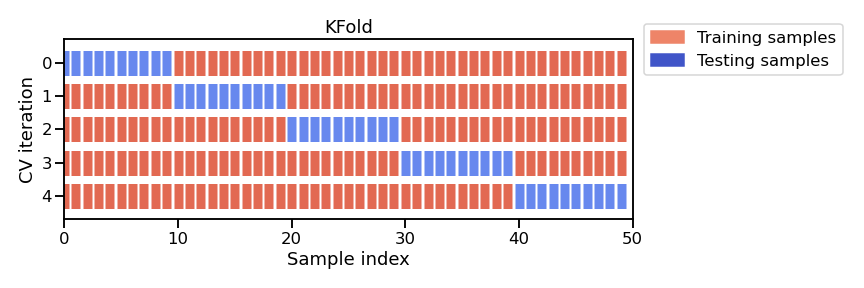

<div class="admonition note alert alert-info">
<p class="first admonition-title" style="font-weight: bold;">Nota</p>
<p class="last">Esta figura mostra o caso particular da estratégia de validação
cruzada <strong>K-fold</strong>. Para cada divisão da validação cruzada, o
procedimento treina um clone do modelo em todas as amostras vermelhas e avalia
o score do modelo nas amostras azuis. Como mencionado anteriormente, existe uma
variedade de diferentes estratégias de validação cruzada. Alguns desses
aspectos serão abordados em mais detalhes em notebooks futuros.</p>
</div>

A validação cruzada é, portanto, computacionalmente intensiva, pois requer o
treinamento de vários modelos em vez de apenas um.

No scikit-learn, a função `cross_validate` permite fazer validação cruzada, e é
necessário passar a ela o modelo, os dados e o alvo. Como existem várias
estratégias de validação cruzada, `cross_validate` recebe um parâmetro `cv` que
define a estratégia de divisão.

In [5]:
%%time
from sklearn.model_selection import cross_validate

model = make_pipeline(StandardScaler(), LogisticRegression())
cv_result = cross_validate(model, data_numeric, target, cv=5)
cv_result

CPU times: user 1.37 s, sys: 15.8 ms, total: 1.39 s
Wall time: 837 ms


{'fit_time': array([0.10013866, 0.1454947 , 0.13243127, 0.12669468, 0.12591577]),
 'score_time': array([0.02846909, 0.0265274 , 0.02659035, 0.02588177, 0.02536201]),
 'test_score': array([0.79557785, 0.80049135, 0.79965192, 0.79873055, 0.80456593])}

A saída de `cross_validate` é um dicionário Python que, por padrão, contém três
entradas:

- (i) o tempo para treinar o modelo nos dados de treino em cada fold, `fit_time`
- (ii) o tempo para prever com o modelo nos dados de teste em cada fold, `score_time`
- (iii) o score padrão nos dados de teste em cada fold, `test_score`.

Definir `cv=5` criou 5 divisões distintas para obter 5 variações dos conjuntos
de treino e teste. Cada conjunto de treino é usado para ajustar um modelo, que
é então pontuado no conjunto de teste correspondente. A estratégia padrão ao
definir `cv=int` é a validação cruzada K-fold, onde `K` corresponde ao número
(inteiro) de divisões. Definir `cv=5` ou `cv=10` é uma prática comum, pois é um
bom equilíbrio entre tempo de computação e estabilidade da variabilidade
estimada.

Note que, por padrão, a função `cross_validate` descarta os `K` modelos que
foram treinados nos diferentes subconjuntos sobrepostos do conjunto de dados. O
objetivo da validação cruzada não é treinar um modelo, mas sim estimar
aproximadamente o desempenho de generalização de um modelo que teria sido
treinado no conjunto de treino completo, junto com uma estimativa da
variabilidade (incerteza sobre a acurácia de generalização).

Você pode passar parâmetros adicionais para
[`sklearn.model_selection.cross_validate`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)
para coletar informações adicionais, como os scores de treino dos modelos
obtidos em cada rodada, ou até mesmo retornar os próprios modelos em vez de
descartá-los. Esses recursos serão abordados em um notebook futuro.

Vamos extrair os scores calculados no fold de teste de cada rodada de validação
cruzada a partir do dicionário `cv_result` e calcular a acurácia média e a
variação da acurácia entre os folds.

In [6]:
scores = cv_result["test_score"]
print(
    "A acurácia média da validação cruzada é: "
    f"{scores.mean():.3f} ± {scores.std():.3f}"
)

A acurácia média da validação cruzada é: 0.800 ± 0.003


Note que, ao calcular o desvio padrão dos scores da validação cruzada, podemos
estimar a incerteza do desempenho de generalização do nosso modelo. Essa é a
principal vantagem da validação cruzada e pode ser crucial na prática, por
exemplo, ao comparar diferentes modelos para descobrir se um é melhor que o
outro ou se nossas medidas de desempenho de generalização de cada modelo estão
dentro das barras de erro uma da outra.

Neste caso específico, apenas as 2 primeiras casas decimais parecem confiáveis.
Se você voltar a este notebook, pode verificar que o desempenho obtido com a
validação cruzada é compatível com o de uma única divisão treino-teste.

## Recapitulando o notebook

Neste notebook, avaliamos o desempenho de generalização do nosso modelo por
meio da **validação cruzada**.